# 04.1 – Observation Models (Univariate)

Observation models specify the probability distribution we assume within each
run-length segment. Fast-BOCPD ships with conjugate models implemented in C,
giving us exact Bayesian updates for multiple data types without compromising
speed. This notebook explains what each model represents, when to choose it,
and how to wire it into the detector.


## 0. Environment setup


In [1]:
import sys
from pathlib import Path

CWD = Path.cwd()
REPO_ROOT = CWD if (CWD / "fast_bocpd").exists() else CWD.parent
EXAMPLES_DIR = REPO_ROOT / "examples"

sys.path.append(str(REPO_ROOT))
sys.path.append(str(EXAMPLES_DIR))


## 1. Imports and shared helpers


In [2]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from fast_bocpd import (
    BOCPD,
    BernoulliBeta,
    BinomialBeta,
    ConstantHazard,
    GaussianNIG,
    GammaGamma,
    PoissonGamma,
    StudentTNG,
)

from _helpers import generate_piecewise_gaussian, plot_series_with_cp, seed_everything


### Helper utilities

``run_bocpd_series`` executes streaming updates and returns a tidy
dataframe with changepoint probabilities and MAP run length. We'll reuse it
for every model-specific example below.


In [3]:
seed_everything(21)

def run_bocpd_series(values, model, hazard, max_run_length=400):
    """Run Fast-BOCPD sequentially and collect diagnostics."""
    values = np.asarray(values)
    bocpd = BOCPD(obs_model=model, hazard=hazard, max_run_length=max_run_length)
    cp_probs = []
    map_run = []
    for value in values:
        _, cp_prob = bocpd.update(float(value))
        cp_probs.append(cp_prob)
        map_run.append(bocpd.get_map_run_length())
    return pd.DataFrame(
        {
            "t": np.arange(len(values)),
            "value": values,
            "cp_prob": np.array(cp_probs),
            "map_r": np.array(map_run),
        }
    )


## 2. What observation models encode

* Each model corresponds to a likelihood + conjugate prior combination. For a
  Gaussian likelihood we track Normal-Inverse-Gamma sufficient statistics,
  for Bernoulli we track Beta counts, etc.
* The choice reflects how we believe data inside one segment behaves. Pick a
  model whose distribution family matches the key properties of your signal
  (continuous vs. discrete, heavy-tailed vs. light-tailed, bounded vs.
  unbounded, positive-only, and so on).
* The hazard function and ``max_run_length`` control *when* we expect
  changepoints, but the observation model controls *how much evidence* is
  needed before we believe the data has shifted.


| Model | Data type | Strengths | Limitations |
| --- | --- | --- | --- |
| ``GaussianNIG`` | Continuous, roughly normal | Very fast, interpretable hyperparameters | Sensitive to outliers or heavy tails |
| ``StudentTNG`` | Continuous with occasional spikes | Handles outliers via heavy-tailed predictive | Need to set degrees of freedom ``nu`` |
| ``StudentTNG (grid mode)`` | Unknown tail behavior | Lets posterior pick ``nu`` adaptively | Slightly higher cost than fixed ``nu`` |
| ``PoissonGamma`` | Non-negative integer counts | Captures rate shifts in event processes | Assumes Poisson variance = mean |
| ``BernoulliBeta`` | Binary 0/1 outcomes | Exact treatment of successes/failures | Works only on single-trial data |
| ``BinomialBeta`` | Aggregated successes out of ``n_trials`` | Avoids manual batching, retains integer counts | Requires fixed ``n_trials`` per datum |
| ``GammaGamma`` | Positive continuous with fixed shape | Ideal for waiting times, durations, scale shifts | Requires choosing/knowing the Gamma ``shape`` |

``StudentTNG`` switches to grid mode automatically when ``nu`` is an array; we list it separately because the behaviour and tuning intuition differ from the fixed-``nu`` case.


We'll now walk through each model, highlight the assumptions, and show a
minimal example. All figures overlay the simulated ground-truth changepoints
to clarify how detection quality changes model by model.


### GaussianNIG – fast baseline for well-behaved sensors

``GaussianNIG`` assumes that observations inside a segment follow a Normal
distribution with unknown mean and variance. The hyperparameters
``mu0``, ``kappa0``, ``alpha0`` and ``beta0`` encode your prior belief about the
mean and variance. This model is ideal when inputs are already z-scored or
when sensors deliver low-noise measurements.

* Use larger ``kappa0`` / ``alpha0`` when you want to trust the prior and
  require more evidence before declaring a shift.
* Reduce ``kappa0`` / ``alpha0`` for more reactive behavior (at the expense
  of false positives on noisy data).
* Prefer Student-t models if the signal can spike unexpectedly.


In [4]:
gaussian_df, gaussian_cps = generate_piecewise_gaussian(
    lengths=[100, 130, 90],
    means=[0.0, 1.2, -0.2],
    sigma=0.25,
    seed=5,
)
gaussian_model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=0.5, beta0=0.5)
gaussian_hazard = ConstantHazard(lambda_=140)
gaussian_results = run_bocpd_series(
    gaussian_df["value"].to_numpy(),
    gaussian_model,
    gaussian_hazard,
    max_run_length=400,
)
fig = plot_series_with_cp(
    gaussian_results,
    value_col="value",
    cp_prob_col="cp_prob",
    changepoints=gaussian_cps,
    title="GaussianNIG tracks mean shifts in a smooth signal",
)
fig


### StudentTNG – robustness to sporadic outliers

``StudentTNG`` replaces the Gaussian predictive with a Student-t predictive
distribution controlled by ``nu`` (degrees of freedom). Low ``nu`` values
yield heavy tails, so the posterior will discount isolated spikes rather than
triggering changepoints immediately.

In the example below we inject extreme outliers into an otherwise mild series
to show how Student-t keeps the changepoint probability flat while still
reacting when the mean really shifts.


In [5]:
student_df, student_cps = generate_piecewise_gaussian(
    lengths=[120, 90, 110],
    means=[0.0, 0.4, -0.1],
    sigma=0.25,
    seed=11,
)
rng = np.random.default_rng(33)
spike_idx = rng.choice(student_df.index, size=6, replace=False)
student_df.loc[spike_idx, "value"] += rng.normal(0.0, 4.5, size=len(spike_idx))
student_values = student_df["value"].to_numpy()
student_model = StudentTNG(mu0=0.0, kappa0=0.4, alpha0=2.5, beta0=0.4, nu=4.0)
student_hazard = ConstantHazard(lambda_=130)
student_results = run_bocpd_series(student_values, student_model, student_hazard)
gaussian_baseline = GaussianNIG(mu0=0.0, kappa0=0.4, alpha0=2.5, beta0=0.4)
gaussian_results_noisy = run_bocpd_series(student_values, gaussian_baseline, student_hazard)
fig = plot_series_with_cp(
    student_results,
    value_col="value",
    cp_prob_col="cp_prob",
    changepoints=student_cps,
    title="StudentTNG shrugs off isolated spikes",
)
if len(fig.data) > 1:
    fig.data[1].name = "P(CP) – Student-t"
fig.add_trace(
    go.Scatter(
        x=gaussian_results_noisy["t"],
        y=gaussian_results_noisy["cp_prob"],
        name="P(CP) – Gaussian",
        mode="lines",
        line=dict(color="#800080", width=2, dash="dash"),
        yaxis="y2",
    )
)
fig


### StudentTNG (grid mode) – adaptively learn tail heaviness

When you do not know how heavy the tails are, passing an array of ``nu`` values to ``StudentTNG`` activates grid mode and integrates
over several candidate ``nu`` values. The posterior blends them according to
how well each explains the data, so you get robustness when needed without
always paying for heavy tails.


In [6]:
rng = np.random.default_rng(3)
lengths = [100, 120, 120]
means = [0.0, 1.5, 0.0]
sigmas = [0.25, 0.9, 0.25]
values = []
total = 0
cps = []
for length, mean, sigma in zip(lengths, means, sigmas):
    if sigma > 0.5:
        seg = mean + 0.3 * rng.standard_t(df=3, size=length)
    else:
        seg = mean + sigma * rng.standard_normal(size=length)
    values.append(seg)
    total += length
    cps.append(total)
    
cps = cps[:-1]
series = np.concatenate(values)
nu_grid = np.array([3.0, 5.0, 10.0, 30.0])
nu_prior = np.array([0.25, 0.35, 0.25, 0.15])
grid_model = StudentTNG(
    mu0=0.0,
    kappa0=0.4,
    alpha0=1.8,
    beta0=0.3,
    nu=nu_grid,
    nu_prior=nu_prior,
)
grid_hazard = ConstantHazard(lambda_=150)
grid_results = run_bocpd_series(series, grid_model, grid_hazard, max_run_length=600)
fig = plot_series_with_cp(
    grid_results,
    value_col="value",
    cp_prob_col="cp_prob",
    changepoints=cps,
    title="StudentT grid adapts between light and heavy tails",
)
fig

### PoissonGamma – event counts / arrival rates

``PoissonGamma`` models integer counts where the variance roughly matches the
mean (Poisson assumption). Typical applications include queue lengths,
arrival processes, and monitoring API call volumes. Hyperparameters
``alpha0`` and ``beta0`` define a Gamma prior on the Poisson rate λ.


In [7]:
rng = np.random.default_rng(10)
segments = [
    (160, 1.0),
    (190, 5.5),
    (160, 0.7),
]
counts = []
cps = []
total = 0
for length, rate in segments:
    counts.append(rng.poisson(rate, size=length))
    total += length
    cps.append(total)

cps = cps[:-1]
counts = np.concatenate(counts)
poisson_model = PoissonGamma(alpha0=1.5, beta0=1.0)
poisson_hazard = ConstantHazard(lambda_=120)
poisson_results = run_bocpd_series(counts, poisson_model, poisson_hazard, max_run_length=600)
fig = plot_series_with_cp(
    poisson_results,
    value_col="value",
    cp_prob_col="cp_prob",
    changepoints=cps,
    title="PoissonGamma detects clear rate shifts in count data",
)
fig

### BernoulliBeta – binary success streams

``BernoulliBeta`` expects single-trial binary data (0 or 1). The Beta prior is
parameterized by ``alpha0`` (prior successes) and ``beta0`` (prior failures).
Use it for click/no-click events, equipment on/off states, or any Boolean
telemetry. ``strict=True`` enforces that inputs are exactly 0 or 1.


In [8]:
rng = np.random.default_rng(8)
segments = [
    (160, 0.04),
    (200, 0.72),
    (160, 0.2),
]
binary = []
cps = []
total = 0
for length, p in segments:
    binary.append(rng.binomial(1, p, size=length))
    total += length
    cps.append(total)

cps = cps[:-1]
binary = np.concatenate(binary)
bernoulli_model = BernoulliBeta(alpha0=0.6, beta0=0.6, strict=True)
bernoulli_hazard = ConstantHazard(lambda_=120)
bernoulli_results = run_bocpd_series(binary, bernoulli_model, bernoulli_hazard, max_run_length=500)
fig = plot_series_with_cp(
    bernoulli_results,
    value_col="value",
    cp_prob_col="cp_prob",
    changepoints=cps,
    title="BernoulliBeta picks up abrupt shifts in binary rates",
)
fig

### BinomialBeta – aggregated successes out of \(n_{trials}\)

When raw binary events arrive in batches (e.g., 20 signups observed every
minute), ``BinomialBeta`` lets you feed the aggregated count while still
respecting the conjugate Beta-Binomial math. Specify ``n_trials`` to match the
number of opportunities per data point.


In [9]:
rng = np.random.default_rng(19)
lengths = [110, 130, 110]
probs = [0.25, 0.6, 0.35]
n_trials = 20
counts = []
cps = []
total = 0
for length, p in zip(lengths, probs):
    counts.append(rng.binomial(n_trials, p, size=length))
    total += length
    cps.append(total)
cps = cps[:-1]
counts = np.concatenate(counts)
binom_model = BinomialBeta(alpha0=1.0, beta0=1.0, n_trials=n_trials)
binom_hazard = ConstantHazard(lambda_=140)
binom_results = run_bocpd_series(counts, binom_model, binom_hazard)
fig = plot_series_with_cp(
    binom_results,
    value_col="value",
    cp_prob_col="cp_prob",
    changepoints=cps,
    title="BinomialBeta monitors aggregated conversion counts",
)
fig


### GammaGamma – positive-valued measurements with fixed shape

``GammaGamma`` targets positive continuous data whose shape parameter stays
roughly constant (waiting times, lifetimes, costs). You control the prior on
the rate via ``alpha0``/``beta0`` and optionally specify a known Gamma shape
``k``. Setting ``shape=1`` reduces to an Exponential likelihood.


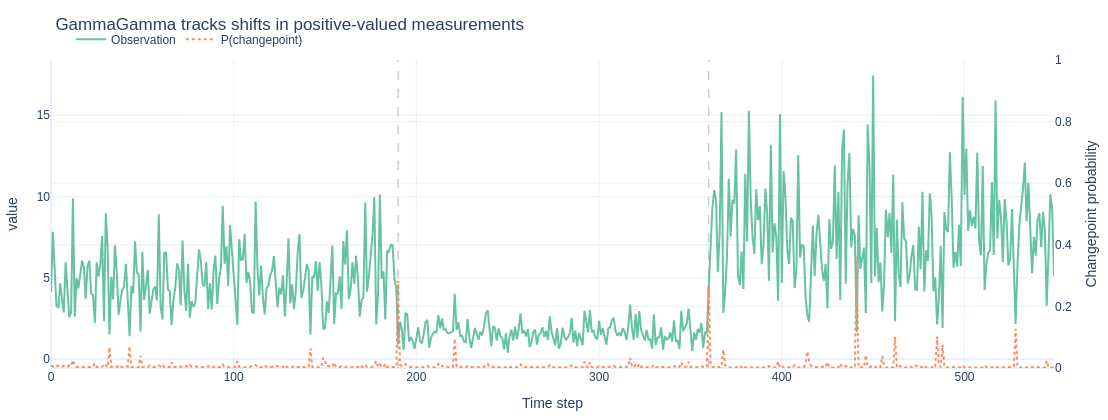

In [10]:
rng = np.random.default_rng(20)
shape = 7.0
segments = [
    (190, 1.4),
    (170, 4.2),
    (190, 0.9),
]
positive = []
cps = []
total = 0
for length, rate in segments:
    scale = 1.0 / rate
    positive.append(rng.gamma(shape, scale=scale, size=length))
    total += length
    cps.append(total)

cps = cps[:-1]
positive = np.concatenate(positive)
gamma_model = GammaGamma(alpha0=2.5, beta0=1.0, shape=shape)
gamma_hazard = ConstantHazard(lambda_=140)
gamma_results = run_bocpd_series(positive, gamma_model, gamma_hazard, max_run_length=650)
fig = plot_series_with_cp(
    gamma_results,
    value_col="value",
    cp_prob_col="cp_prob",
    changepoints=cps,
    title="GammaGamma tracks shifts in positive-valued measurements",
)
fig

## 3. Choosing between models

* Start with the model that matches your measurement scale (continuous,
  count, binary, positive-only).
* Switch from Gaussian to Student-t when you see frequent outliers or sudden
  variance spikes.
* Use the Binomial variant whenever you already aggregate binary events into
  fixed-size batches; otherwise prefer the Bernoulli model for raw streams.
* Poisson vs. Gamma: counts (including zeros) belong to PoissonGamma,
  whereas strictly positive durations/amounts belong to GammaGamma.

Once you know which observation family to use, tune the hazard function and
``max_run_length`` as described in the dedicated hazard notebook (04.3). The
observation model and hazard together give you the right balance between
sensitivity and stability.
